In [6]:
import sys

sys.path.insert(0, '..')

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
# from contrib.ha_traj import load_and_group_trajectories

# hardware_to_trajs = load_and_group_trajectories()

all_trajs = list(Path('../result/ha').glob('*.json'))

In [7]:
import json

def read_traj(file):
    data = json.loads(file.read_text())
    res = {
        'hardware': data['hardware_name'],
        'depth_ratio': data['metrics']['depth_ratio'],
        'cx_ratio': data['metrics']['cx_ratio'],
        'init': data['init']
    }
    return res


records = list(map(read_traj, all_trajs))
records


[{'hardware': 'sycamore',
  'depth_ratio': 2.2018348623853212,
  'cx_ratio': 8.18918918918919,
  'init': 'random'},
 {'hardware': 'rochester',
  'depth_ratio': 3.206896551724138,
  'cx_ratio': 5.53781512605042,
  'init': 'sabre'},
 {'hardware': 'rochester',
  'depth_ratio': 4.142857142857143,
  'cx_ratio': 4.060913705583756,
  'init': 'sabre'},
 {'hardware': 'sycamore',
  'depth_ratio': 2.5689655172413794,
  'cx_ratio': 5.732394366197183,
  'init': 'random'},
 {'hardware': 'rochester',
  'depth_ratio': 7.395833333333333,
  'cx_ratio': 7.904306220095694,
  'init': 'random'},
 {'hardware': 'rochester',
  'depth_ratio': 8.162790697674419,
  'cx_ratio': 10.47191011235955,
  'init': 'identity'},
 {'hardware': 'rochester',
  'depth_ratio': 7.655172413793103,
  'cx_ratio': 12.68421052631579,
  'init': 'identity'},
 {'hardware': 'rochester',
  'depth_ratio': 4.634408602150538,
  'cx_ratio': 12.595092024539877,
  'init': 'identity'},
 {'hardware': 'rochester',
  'depth_ratio': 7.220588235294118

In [8]:
df = pd.DataFrame.from_records(records)
df

,hardware,depth_ratio,cx_ratio,init
0,sycamore,2.201835,8.189189,random
1,rochester,3.206897,5.537815,sabre
2,rochester,4.142857,4.060914,sabre
3,sycamore,2.568966,5.732394,random
4,rochester,7.395833,7.904306,random
...,...,...,...,...
4631,rochester,3.696970,6.544304,sabre
4632,tokyo,1.688312,3.108108,random
4633,sycamore,5.242424,7.535714,random
4634,sycamore,4.382716,4.555556,sa


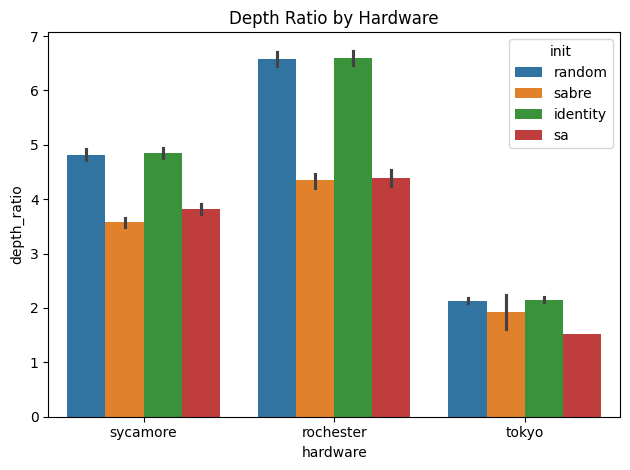

In [9]:
sns.barplot(x='hardware', y='depth_ratio', hue='init', data=df)
plt.title('Depth Ratio by Hardware')
plt.tight_layout()
plt.savefig('depth_ratio_by_hardware.png')

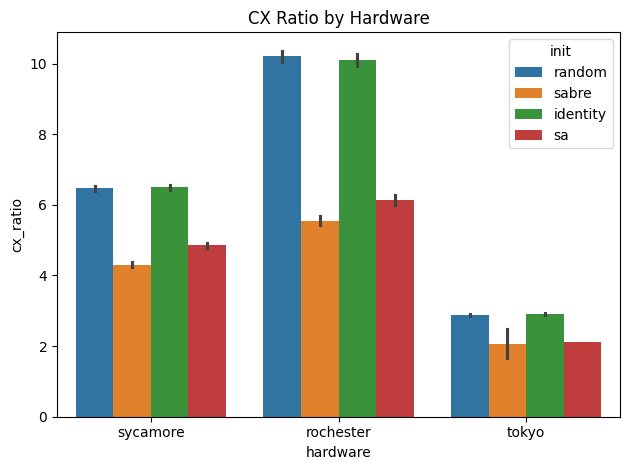

In [10]:
sns.barplot(x='hardware', y='cx_ratio', hue='init', data=df)
plt.title('CX Ratio by Hardware')
plt.tight_layout()
plt.savefig('cx_ratio_by_hardware.png')